# Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Read data

In [21]:
df = pd.read_json("../data/raw/Sarcasm_Headlines_Dataset.json", lines= True)

In [22]:
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


## Dataset Overview

In [23]:
df.shape

(28619, 3)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


In [25]:
df["is_sarcastic"].value_counts()

0    14985
1    13634
Name: is_sarcastic, dtype: int64

## Missing Values

In [26]:
df.isnull().sum()

is_sarcastic    0
headline        0
article_link    0
dtype: int64

In [27]:
df.isna().sum()

is_sarcastic    0
headline        0
article_link    0
dtype: int64

### Checking for Duplicates

In [28]:
df.duplicated().sum()

2

## Headline length Analysis

We compare headline lengths to determine whether text length may differ between sarcastic and non-sarcastic examples.

In [39]:
df["headline_length"] = df['headline'].str.len()
df["word_count"] = df['headline'].str.split().str.len()

df[["headline_length", "word_count"]].describe()

,headline_length,word_count
count,28619.000000,28619.000000
mean,62.308571,10.049967
std,20.726483,3.388307
min,7.000000,2.000000
25%,49.000000,8.000000
50%,62.000000,10.000000
75%,75.000000,12.000000
max,926.000000,151.000000


# Class distribution

We first examine whether the dataset is balanced between sarcastic and non-sarcastic headlines.

In [ ]:

df["is_sarcastic"].value_counts()

0    14985
1    13634
Name: is_sarcastic, dtype: int64

In [30]:
# Class distribution as percentages
df["is_sarcastic"].value_counts(normalize=True) * 100

0    52.36032
1    47.63968
Name: is_sarcastic, dtype: float64

In [34]:
df.groupby("is_sarcastic")[["headline_length", "word_count"]].mean()

,headline_length,word_count
is_sarcastic,,
0,59.558625,9.815616
1,65.331011,10.307540


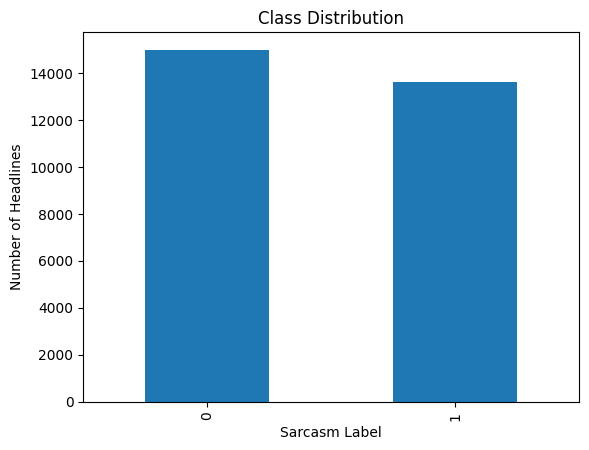

In [35]:
df["is_sarcastic"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sarcasm Label")
plt.ylabel("Number of Headlines")
plt.show()

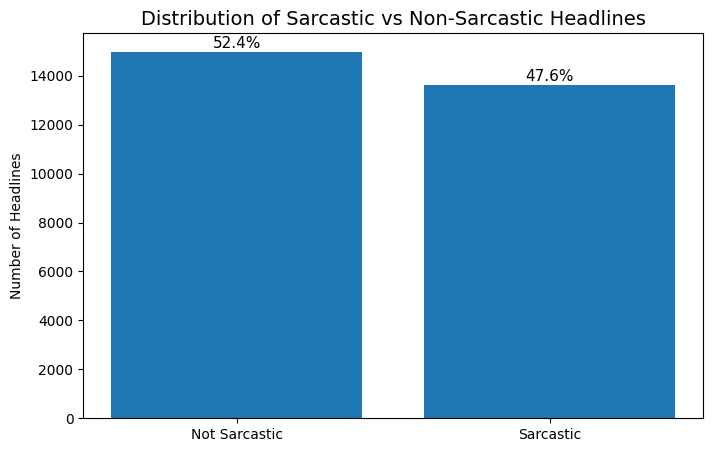

In [38]:
class_counts = df["is_sarcastic"].value_counts().sort_index()
class_percentages = class_counts / class_counts.sum() * 100

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Not Sarcastic", "Sarcastic"],
    class_counts.values
)

plt.title("Distribution of Sarcastic vs Non-Sarcastic Headlines", fontsize=14)
plt.ylabel("Number of Headlines")

for bar, pct in zip(bars, class_percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{pct:.1f}%",
        ha="center",
        fontsize=11
    )

plt.show()


## Sample sarcastic/non-sarcastic headlines

In [40]:
df[df["is_sarcastic"] == 1][["headline"]].head(10)

,headline
0,thirtysomething scientists unveil doomsday clo...
3,inclement weather prevents liar from getting t...
4,mother comes pretty close to using word 'strea...
7,richard branson's global-warming donation near...
8,shadow government getting too large to meet in...
14,ford develops new suv that runs purely on gaso...
16,area boy enters jumping-and-touching-tops-of-d...
17,area man does most of his traveling by gurney
21,guard in video game under strict orders to rep...
25,secret service agent not so secret about being...


In [41]:
df[df["is_sarcastic"] == 0][["headline"]].head(10)

,headline
1,dem rep. totally nails why congress is falling...
2,eat your veggies: 9 deliciously different recipes
5,my white inheritance
6,5 ways to file your taxes with less stress
9,lots of parents know this scenario
10,this lesbian is considered a father in indiana...
11,amanda peet told her daughter sex is 'a specia...
12,what to know regarding current treatments for ...
13,chris christie suggests hillary clinton was to...
15,uber ceo travis kalanick stepping down from tr...


In [42]:
df["headline"].duplicated().sum()

116

In [43]:
df[df["headline"].duplicated(keep=False)].sort_values("headline").head(20)

,is_sarcastic,headline,article_link,headline_length,word_count
7260,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
12216,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
12856,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
10254,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
10139,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
18118,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
15499,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
7184,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
5806,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12
5060,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...,71,12


## Initial Observations

- The dataset is reasonably balanced between sarcastic and non-sarcastic headlines.
- There are no major missing-value issues.
- Headline lengths appear broadly similar across both classes.
- Some duplicate headlines may need to be removed before model training.
- Sarcasm often depends on semantic incongruity rather than obvious keywords.